#### Import Libraries and Data

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.optimize import minimize

In [109]:
energy = pd.read_excel('/content/drive/MyDrive/ML datasets/ENB2012_data.xlsx')

#### EDA

In [110]:
energy.head()

,Relative Compactness\t,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load,Cooling Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [111]:
energy.isnull().sum()

,0
Relative Compactness\t,0
Surface Area,0
Wall Area,0
Roof Area,0
Overall Height,0
Orientation,0
Glazing Area,0
Glazing Area Distribution,0
Heating Load,0
Cooling Load,0


In [112]:
energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative Compactness	      768 non-null    float64
 1   Surface Area               768 non-null    float64
 2   Wall Area                  768 non-null    float64
 3   Roof Area                  768 non-null    float64
 4   Overall Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing Area               768 non-null    float64
 7   Glazing Area Distribution  768 non-null    int64  
 8   Heating Load               768 non-null    float64
 9   Cooling Load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [113]:
round(energy.describe(), 4)

,Relative Compactness\t,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load,Cooling Load
count,768.0000,768.0000,768.0000,768.0000,768.0000,768.0000,768.0000,768.0000,768.0000,768.0000
mean,0.7642,671.7083,318.5000,176.6042,5.2500,3.5000,0.2344,2.8125,22.3072,24.5878
std,0.1058,88.0861,43.6265,45.1660,1.7511,1.1188,0.1332,1.5510,10.0902,9.5133
min,0.6200,514.5000,245.0000,110.2500,3.5000,2.0000,0.0000,0.0000,6.0100,10.9000
25%,0.6825,606.3750,294.0000,140.8750,3.5000,2.7500,0.1000,1.7500,12.9925,15.6200
50%,0.7500,673.7500,318.5000,183.7500,5.2500,3.5000,0.2500,3.0000,18.9500,22.0800
75%,0.8300,741.1250,343.0000,220.5000,7.0000,4.2500,0.4000,4.0000,31.6675,33.1325
max,0.9800,808.5000,416.5000,220.5000,7.0000,5.0000,0.4000,5.0000,43.1000,48.0300


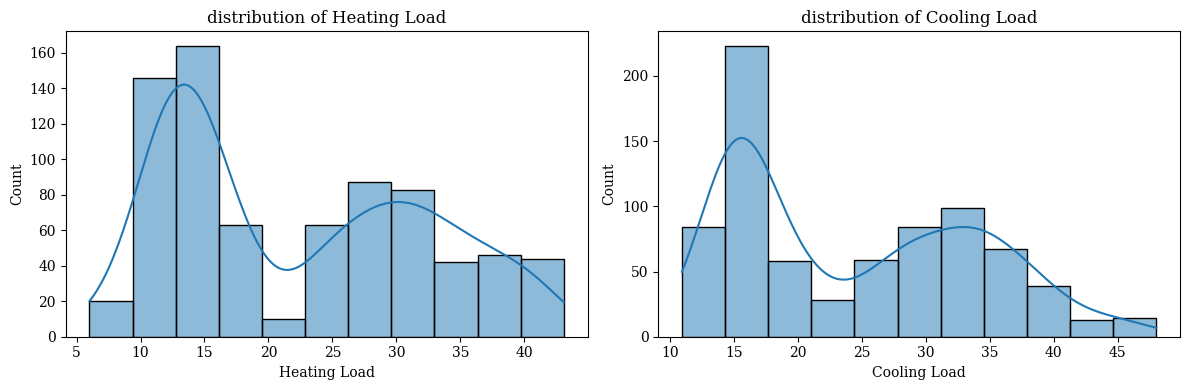

In [114]:
# distribution of target variables

fig, axes = plt.subplots(1, 2, figsize = (12, 4))

sns.histplot(energy['Heating Load'], kde = True, ax=axes[0])
axes[0].set_title('distribution of Heating Load')
axes[0].set_xlabel('Heating Load')

sns.histplot(energy['Cooling Load'], kde = True, ax=axes[1])
axes[1].set_title('distribution of Cooling Load')
axes[1].set_xlabel('Cooling Load')

plt.tight_layout()
plt.show()

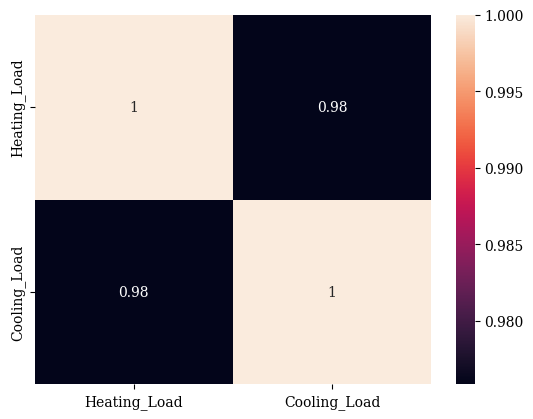

In [115]:
y_corr = y.corr()
sns.heatmap(y_corr, annot = True)
plt.show()

#### Optimization

In [116]:
# defining Feature and target variables
x = energy.drop(['Heating Load', 'Cooling Load'], axis =1)
y = energy[['Heating Load', 'Cooling Load']]

# splitting training and testing set
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 524)

Surrogate Modeling

In [117]:
# Model for Heating load (Y1)
model_heating = RandomForestRegressor(random_state = 24)
model_heating.fit(x_train, y_train['Heating Load'])

# Model for Cooling load (Y2)
model_cooling = RandomForestRegressor(random_state = 24)
model_cooling.fit(x_train, y_train['Cooling Load'])

# predicting and evaluating on test set
pred_heating = model_heating.predict(x_test)
pred_cooling = model_cooling.predict(x_test)

print(f'R2 score for Heating Load: {round(r2_score(y_test['Heating Load'], pred_heating), 4)}')
print(f'R2 score for Cooling Load: {round(r2_score(y_test['Cooling Load'], pred_cooling), 4)}')

R2 score for Heating Load: 0.9962
R2 score for Cooling Load: 0.9695


In [118]:
# setting bounds
bounds = [(x[col].min(), x[col].max()) for col in x.columns]

# defining the objective function
def objective_heating(x):
  x_reshaped = np.array(x).reshape(1, -1)
  return model_heating.predict(x_reshaped)[0]

def objective_cooling(x):
  x_reshaped = np.array(x).reshape(1, -1)
  return model_cooling.predict(x_reshaped)[0]

# initial starting point
initial_guess = x.mean().values

In [119]:
# optimize to minimize Heating Load
results_heating = minimize(
    fun = objective_heating,
    x0 = initial_guess,
    method = "SLSQP",
    bounds = bounds
)

# optimize to minimize Cooling Load
results_cooling = minimize(
    fun = objective_cooling,
    x0 = initial_guess,
    method = 'SLSQP',
    bounds = bounds
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/

In [120]:
print("\n Optimal Design for Minimum Heating Load ")
opt_heating_df = pd.Series(results_heating.x, index=x.columns)
print(f"Minimum Predicted Heating Load: {results_heating.fun:.2f}")
print(opt_heating_df.to_string())

print("\n Optimal Design for Minimum Cooling Load ")
opt_cooling_df = pd.Series(results_cooling.x, index=x.columns)
print(f"Minimum Predicted Cooling Load: {results_cooling.fun:.2f}")
print(opt_cooling_df.to_string())


 Optimal Design for Minimum Heating Load 
Minimum Predicted Heating Load: 30.19
Relative Compactness\t         0.764167
Surface Area                 671.708333
Wall Area                    318.500000
Roof Area                    176.604167
Overall Height                 5.250000
Orientation                    3.500000
Glazing Area                   0.234375
Glazing Area Distribution      2.812500

 Optimal Design for Minimum Cooling Load 
Minimum Predicted Cooling Load: 27.03
Relative Compactness\t         0.764167
Surface Area                 671.708333
Wall Area                    318.500000
Roof Area                    176.604167
Overall Height                 5.250000
Orientation                    3.500000
Glazing Area                   0.234375
Glazing Area Distribution      2.812500


Surrogate-based single-objective optimization revealed a uniform structural profile for minimizing both heating and cooling loads independently.
